# 4. Vector Embeddings (Dense Retrieval)

**RAG Pipeline Series — Notebook 4**

In notebook 3 we built **sparse** representations (TF-IDF, BM25) over `rag.pdf`'s chapter-tagged chunks. Both matched the keyword-style query well, but fell apart on the paraphrased query — because sparse methods can only match words that are literally present in both the query and the chunk.

**Dense embeddings** fix this. A neural network (a "sentence transformer") maps each chunk to a fixed-length vector of real numbers — no zeros — positioned so that *semantically similar* text ends up nearby in vector space, regardless of exact wording.

In this notebook we will:
1. Rebuild the same chapter-tagged chunks used in notebooks 2 and 3.
2. Encode every chunk with a **very small** sentence-transformer model.
3. Search with cosine similarity and compare directly against notebook 3's TF-IDF/BM25 results on the *same* keyword-style and paraphrased queries.
4. Visualize the chunk embeddings in 2D to see chapters cluster by meaning.


## Setup

In [1]:
%pip install -q -U langchain langchain-community pypdf sentence-transformers scikit-learn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


## 1. Recap: loading and chunking `rag.pdf`

Same loading + chapter-aware chunking as notebooks 2 and 3: load pages with `PyPDFLoader`, strip the repeated header/footer lines, split the full text into per-chapter spans, then run `RecursiveCharacterTextSplitter` *within* each chapter so no chunk crosses a chapter boundary. Each chunk keeps its `chapter_num` / `chapter_title` as metadata.

In [ ]:
# Only runs inside Colab. Opens a file picker; select rag.pdf.
# Safe to skip this cell if you're running locally and already have the file on disk.
from rag_utils import maybe_colab_upload

maybe_colab_upload()

In [1]:
from rag_utils import resolve_pdf_path, load_clean_text

# Prefer the Colab upload location; fall back to this repo's dataset/ folder
# when running locally (rag-notebooks/ and dataset/ are sibling folders).
PDF_PATH = resolve_pdf_path()
pages, full_text = load_clean_text(PDF_PATH)

print(f"Loaded {len(pages)} pages from {PDF_PATH}")

d:\youtube\TheAIGuy\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 58 pages from ..\dataset\rag.pdf


In [2]:
from rag_utils import DEFAULT_CHUNK_OVERLAP, DEFAULT_CHUNK_SIZE, chunk_chapters, split_into_chapters

CHUNK_SIZE, CHUNK_OVERLAP = DEFAULT_CHUNK_SIZE, DEFAULT_CHUNK_OVERLAP
chapters = split_into_chapters(full_text)
chunks = chunk_chapters(chapters, chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)

corpus = [d.page_content for d in chunks]
print(f"{len(chapters)} chapters -> {len(chunks)} chapter-tagged chunks")
print(chunks[0].metadata)
print(chunks[0].page_content[:200])

15 chapters -> 181 chapter-tagged chunks
{'chapter_num': '01', 'chapter_title': 'Introduction to RAG'}
Retrieval-Augmented Generation (RAG) is one of the most transformative patterns in modern AI
engineering. It bridges the gap between the remarkable language capabilities of Large Language
Models (LLMs


## 2. Encoding chunks with a very small sentence-transformer

We use [`sentence-transformers/paraphrase-MiniLM-L3-v2`](https://huggingface.co/sentence-transformers/paraphrase-MiniLM-L3-v2) — a tiny 3-layer sentence embedding model (~17M parameters, ~61MB, 384 dimensions). It's small enough to encode on CPU almost instantly, which makes it a good fit for a teaching notebook — a bigger model like `all-mpnet-base-v2` would give higher-quality embeddings, but the same core ideas apply regardless of model size.

In [3]:
from sentence_transformers import SentenceTransformer
import torch

EMBEDDING_MODEL = "sentence-transformers/paraphrase-MiniLM-L3-v2"  # very small: ~17M params, 384-dim
embedder = SentenceTransformer(EMBEDDING_MODEL, device="cuda" if torch.cuda.is_available() else "cpu")

chunk_embeddings = embedder.encode(corpus, normalize_embeddings=True, show_progress_bar=True)

print(f"Embedding dimension: {chunk_embeddings.shape[1]}")
print(f"Chunk vector matrix shape: {chunk_embeddings.shape}")
print(f"\nChunk 0 vector (first 8 of {chunk_embeddings.shape[1]} values):", chunk_embeddings[0][:8])
print("Every dimension carries a real value -- this is what \"dense\" means (contrast with notebook 3's mostly-zero sparse vectors).")

Batches: 100%|██████████| 6/6 [00:28<00:00,  4.73s/it]

Embedding dimension: 384
Chunk vector matrix shape: (181, 384)

Chunk 0 vector (first 8 of 384 values): [-0.05549127  0.02334685  0.01192709  0.10549074 -0.02607335  0.01850454
 -0.00106391 -0.03635149]
Every dimension carries a real value -- this is what "dense" means (contrast with notebook 3's mostly-zero sparse vectors).


## 3. Searching with cosine similarity

Same search pattern as notebook 3 (embed the query, rank chunks by similarity) — but now the embeddings capture meaning, not just vocabulary.

In [4]:
from sentence_transformers import util

def vector_search(query, k=5):
    q_emb = embedder.encode(query, normalize_embeddings=True)
    sims = util.cos_sim(q_emb, chunk_embeddings)[0].numpy()
    order = sims.argsort()[::-1][:k]
    return [(int(i), round(float(sims[i]), 3), chunks[i].metadata["chapter_title"]) for i in order]

## 4. Same queries as notebook 3: keyword-style vs. paraphrased

We reuse the exact same target chunks and queries from notebook 3, so the comparison is apples-to-apples:

- **Keyword-style query** — reuses the BM25 chunk's own vocabulary almost verbatim.
- **Paraphrased query** — describes the hallucination chunk's idea in different words.

In notebook 3, TF-IDF/BM25 ranked the keyword-style query's target chunk highly, but the paraphrased query's target chunk ranked far worse (or missed the top-k entirely).

In [5]:
bm25_chunk_idx = next(i for i, d in enumerate(chunks) if "Okapi Best Match 25" in d.page_content)
hallucination_chunk_idx = next(i for i, d in enumerate(chunks) if "dynamic, external knowledge source" in d.page_content)

keyword_query = "Okapi Best Match 25 term frequency saturation document length normalization"
paraphrase_query = "How can giving a language model outside documents stop it from making things up?"

print("Keyword-style query:", keyword_query)
print("Target chunk:", bm25_chunk_idx, "-", chunks[bm25_chunk_idx].metadata)
print("Vector top-5:", vector_search(keyword_query))

Keyword-style query: Okapi Best Match 25 term frequency saturation document length normalization
Target chunk: 18 - {'chapter_num': '02', 'chapter_title': 'Evolution of Retrieval'}
Vector top-5: [(18, 0.484, 'Evolution of Retrieval'), (60, 0.355, 'Vector Databases & Indexing'), (95, 0.355, 'Re-ranking'), (70, 0.327, 'Retrieval Techniques'), (46, 0.325, 'Embeddings')]


In [6]:
print("Paraphrased query:", paraphrase_query)
print("Target chunk:", hallucination_chunk_idx, "-", chunks[hallucination_chunk_idx].metadata)
print("Vector top-5:", vector_search(paraphrase_query))
print()
print("Compare this rank to notebook 3, where TF-IDF/BM25 struggled badly on this exact same query.")

Paraphrased query: How can giving a language model outside documents stop it from making things up?
Target chunk: 1 - {'chapter_num': '01', 'chapter_title': 'Introduction to RAG'}
Vector top-5: [(31, 0.442, 'Data Ingestion'), (2, 0.44, 'Introduction to RAG'), (105, 0.401, 'Augmentation'), (30, 0.398, 'Data Ingestion'), (12, 0.392, 'Introduction to RAG')]

Compare this rank to notebook 3, where TF-IDF/BM25 struggled badly on this exact same query.


This is the core value proposition of dense retrieval: it generalizes past exact wording. Under the hood, `paraphrase-MiniLM-L3-v2` was trained on sentence pairs to place paraphrases close together and unrelated sentences far apart — no keyword overlap required.

## 5. Comparing all three: where does the correct chunk rank?

Same rank-of-correct-chunk comparison as notebook 3's TF-IDF vs. BM25 table, now with vector search added as a third column.

In [7]:
import pandas as pd

def rank_of(target_idx, results):
    for rank, (idx, score, title) in enumerate(results, start=1):
        if idx == target_idx:
            return rank
    return f"> {len(results)}"

rows = []
for query_name, query, target_idx in [
    ("Keyword-style", keyword_query, bm25_chunk_idx),
    ("Paraphrased", paraphrase_query, hallucination_chunk_idx),
]:
    vector_results = vector_search(query, k=10)
    rows.append({
        "query": query_name,
        "vector_rank": rank_of(target_idx, vector_results),
    })

pd.DataFrame(rows)

,query,vector_rank
0,Keyword-style,1
1,Paraphrased,> 10


## 6. Visualizing the embedding space

Let's project the 384-dimensional chunk embeddings down to 2D with PCA and color by chapter. If the model is doing its job, chunks from the same chapter should tend to cluster together, since they discuss related ideas.

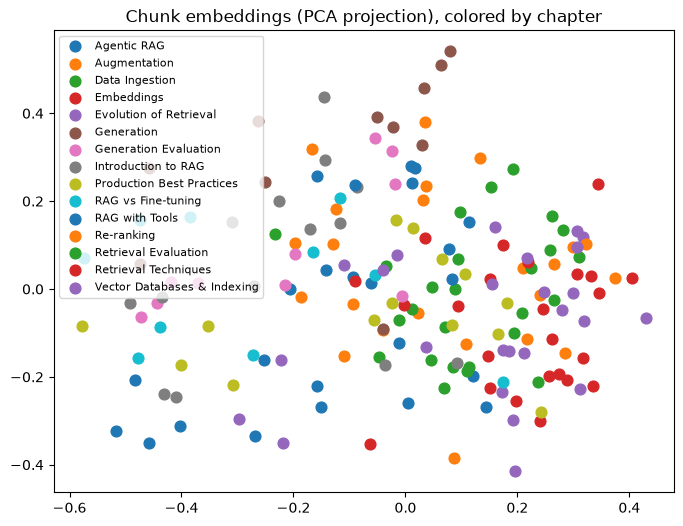

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
points_2d = pca.fit_transform(chunk_embeddings)

chapter_titles = [d.metadata["chapter_title"] for d in chunks]
unique_titles = sorted(set(chapter_titles))
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(8, 6))
for i, title in enumerate(unique_titles):
    mask = [t == title for t in chapter_titles]
    xs = points_2d[mask, 0]
    ys = points_2d[mask, 1]
    ax.scatter(xs, ys, label=title, color=colors[i % len(colors)], s=60)
ax.set_title("Chunk embeddings (PCA projection), colored by chapter")
ax.legend(fontsize=8, loc="best")
plt.show()

Chunks from the same chapter should visibly cluster — even though the model never saw our chapter labels. That clustering is exactly what makes semantic search work: "nearby in embedding space" tends to mean "about the same thing."

*(With only a few dozen short chunks, PCA is used here instead of t-SNE, which is unstable at this scale — t-SNE needs more data points to produce a reliable layout.)*

## Takeaways

- Dense embeddings are fixed-length, real-valued vectors that place semantically similar text close together — this is what fixed the paraphrase-query failure from notebook 3.
- Even a **very small** sentence-transformer (`paraphrase-MiniLM-L3-v2`, ~17M params) captures enough semantics to beat TF-IDF/BM25 on paraphrased queries — you don't need a huge model to see the effect.
- Cosine similarity between normalized embeddings is the standard way to rank chunks by relevance.

**Next up (notebook 5):** instead of manually looping over a NumPy array of embeddings, we'll store them in a proper **vector store** (Chroma) and let it handle the search for us.